# モジュールのインポート

In [1]:
# ---------------------------------------------------------
# 学習用モジュール
# ---------------------------------------------------------
import os
import sys
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split # 追加
from datetime import datetime

# ---------------------------------------------------------
# 各種自作モジュール
# ---------------------------------------------------------
_colab_dir = "/content/drive/MyDrive/hioki_lab/src/voice_synthesis/DDSP_VAE_twostream"
os.chdir(_colab_dir)
# これをインポートの前に必ず入れる！
if _colab_dir not in sys.path:
    sys.path.append(_colab_dir)

from dataset import RealAudioDataset  # あなたのデータセットクラス
from models.encoder import FeatureEncoder
from models.ddsp_decoder import DDSPDecoder # 既存のDDSPデコーダ
from models.discriminator import SpectrogramDiscriminator
from models.vae_ddsp import VAE_DDSP
from criterions.losses import VAEGANLossManager
from engine.trainer import VAEGANTrainer

# ---------------------------------------------------------
# 評価用モジュール
# ---------------------------------------------------------
import torch
import IPython.display as ipd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np

# Config

In [2]:
# ==========================================
# 1. 唯一の設定情報 (Single Source of Truth)
# ==========================================
config = {
    # --- オーディオ・信号処理設定 ---
    "sample_rate": 16000,
    "n_fft": 2048,
    "hop_length": 64,       # 4ms
    "chunk_sec": 4.0,       # 切り取り秒数

    # --- DDSPシンセサイザー設定 ---
    "n_harmonics": 60,
    "n_noise_bands": 65,

    # --- モデル構造設定 ---
    # "feature_dim": 19,      # MFCCの次元数
    "mel_frequency": 80,      # メルの周波数バンド数
    "latent_dim": 16,       # 潜在表現Zの次元数
    "hidden_size": 256, # デコーダ―における隠れ層数の設定
    "n_layers": 1, # gruの層数設定

    # --- 学習(Trainer)設定 ---
    "batch_size": 16,
    "learning_rate": 1e-4,  # lr_G, lr_D として分けてもOK
    "epochs": 50,
    "beta_max": 0.001,
    "warmup_steps": 2000,
    "val_ratio": 0.2, # 20%を検証用に
    "lr_G": 1e-4,
    "lr_D": 1e-4,

    # --- パス設定 ---
    "data_dir": "/content/drive/MyDrive/hioki_lab/data/URMP_solo_inst/processed_data",
    "base_save_dir": "/content/drive/MyDrive/hioki_lab/src/voice_synthesis/DDSP_VAE_twostream/saved_checkpoint",
    "experiment_name": "exp_002_vaegan_baseline",

    # ---デバイス設定---
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

# 学習ループ

In [3]:
def main(mode="train"):

    # chunk_secをもとにフレーム数（サンプル数）をあらかじめ計算
    config["chunk_frames"] = int(config["sample_rate"] * config["chunk_sec"])

    # 保存先ディレクトリの作成
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    exp_dir = os.path.join(config["base_save_dir"], f"{config["experiment_name"]}_{timestamp}")

    os.makedirs(exp_dir, exist_ok=True)
    print(f"Using device: {config['device']}")

    # ==========================================
    # 2. データセットとデータローダーの準備
    # ==========================================
    # ※ここはご自身のデータセットのパスやクラス名に合わせて調整してください
    print("Loading datasets...")
    all_files = glob.glob(os.path.join(config["data_dir"], "*.pt"))

    if len(all_files) == 0:
        raise ValueError(f"No files found in {config['data_dir']}")

    # 楽器ラベルをもとに、データセットを学習用と検証用に均等に分ける処理
    labels = [os.path.basename(f).split('_')[0] for f in all_files]
    train_files, val_files = train_test_split(
        all_files,
        test_size=config["val_ratio"],
        random_state=42,    # 乱数シードを固定（毎回同じ分け方にするため必須）
        stratify=labels     # 楽器の比率をTrainとValで均等にする魔法の引数
    )

    print(f"Total files: {len(all_files)} | Train: {len(train_files)} | Val: {len(val_files)}")

    # filepathのリストをデータセットクラスでラップする。
    train_dataset = RealAudioDataset(
        train_files,
        crop_len_sec=config["chunk_sec"],
        sample_rate=config["sample_rate"],
        hop_length=config["hop_length"]
    )
    val_dataset = RealAudioDataset(
        val_files,
        crop_len_sec=config["chunk_sec"],
        sample_rate=config["sample_rate"],
        hop_length=config["hop_length"]
    )

    # dataloaderには各ファイルパスにおけるdatasetのインスタンスが渡される。
    train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=config["batch_size"], shuffle=False)

    # ==========================================
    # 3. モデルのインスタンス化
    # ==========================================
    print("Initializing models...")
    encoder = FeatureEncoder(input_channels=config["mel_frequency"], hidden_dim=config["hidden_size"], latent_dim=config["latent_dim"])
    decoder = DDSPDecoder(
      latent_dim=config["latent_dim"],
      hidden_size=config["hidden_size"],
      n_layers=config["n_layers"],
      n_harmonics=config["n_harmonics"],
      n_noise_bands=config["n_noise_bands"],
      sample_rate=config["sample_rate"],
      hop_length=config["hop_length"],
      n_fft=config["n_fft"]
    )

    # ジェネレーター (VAE + DDSP) と ディスクリミネーター
    generator = VAE_DDSP(encoder, decoder)
    discriminator = SpectrogramDiscriminator(
        sample_rate=config["sample_rate"],
        n_fft=config["n_fft"],
        hop_length=config["hop_length"],
        n_mels=config["mel_frequency"]
    )

    # ==========================================
    # 4. 損失関数 (Criterion) と オプティマイザの準備
    # ==========================================
    # Lossの重みバランスなどもここで一元指定します
    criterion = VAEGANLossManager(
        lambda_recon=10.0,
        lambda_kl=0.001,
        lambda_adv=0.1
    )

    # GとDで別々のオプティマイザを用意（GANの鉄則）
    opt_G = optim.Adam(generator.parameters(), lr=config["lr_G"], betas=(0.5, 0.999))
    opt_D = optim.Adam(discriminator.parameters(), lr=config["lr_D"], betas=(0.5, 0.999))

    # ==========================================
    # 5. Trainerの初期化と学習の実行
    # ==========================================
    print("Setting up Trainer...")
    trainer = VAEGANTrainer(
        generator=generator,
        discriminator=discriminator,
        criterion=criterion,
        opt_G=opt_G,
        opt_D=opt_D,
        train_loader=train_loader,
        save_dir=config["base_save_dir"], # Trainer側で保存先を受け取るように少し修正する想定
        val_loader=None, # バリデーションがある場合に変更
        device=config["device"],

    )

    # 学習時
    if mode == "train":
        trainer.train(num_epochs=config["epochs"])
        print("Training completed successfully.")
    # 評価時
    elif mode == "test":
      return generator, train_dataset


# 評価用コード

In [4]:
import torch
import IPython.display as ipd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np

def test_reconstruction(model, dataset, checkpoint_path, idx=0, device="cuda"):
    # 1. モデルの重みをロード
    checkpoint = torch.load(checkpoint_path, map_location=device)
    # Trainerのsave_checkpointの仕様に合わせて 'generator_state_dict' を取得
    model.load_state_dict(checkpoint['generator_state_dict'])
    model.to(device)
    model.eval() # 推論モード（BatchNormやReparameterizeを固定）

    # 2. データの準備
    batch = dataset[idx]
    mel = batch['mel'].unsqueeze(0).to(device)
    f0_hz = batch['f0_hz'].unsqueeze(0).to(device)
    f0_norm = batch['f0_norm'].unsqueeze(0).to(device)
    loudness_norm = batch['loudness_norm'].unsqueeze(0).to(device)
    real_audio = batch['audio'].cpu().numpy()
    # rms = batch['rms'].unsqueeze(0).to(device)

    # 3. 再合成の実行
    with torch.no_grad():
        # VAE-DDSPのforwardを実行
        audio_gen, mu, log_var = model(mel, f0_hz, f0_norm, loudness_norm)
        gen_audio = audio_gen.squeeze().cpu().numpy()

    # 4. 音声の表示
    print(f"--- 試聴中の楽器: {batch['inst_name']} (Index: {idx}) ---")
    print("Original Audio:")
    ipd.display(ipd.Audio(real_audio, rate=16000))
    print("Reconstructed Audio (Epoch 10):")
    ipd.display(ipd.Audio(gen_audio, rate=16000))

    # 5. 可視化 (波形とスペクトログラム)
    plot_comparison(real_audio, gen_audio)

def plot_comparison(real, gen):
    plt.figure(figsize=(15, 10))

    # 波形の比較
    plt.subplot(2, 1, 1)
    plt.plot(real, label='Real', alpha=0.5)
    plt.plot(gen, label='Generated', alpha=0.5)
    plt.title("Waveform Comparison")
    plt.legend()

    # スペクトログラムの比較
    plt.subplot(2, 2, 3)
    S_real = librosa.amplitude_to_db(np.abs(librosa.stft(real)), ref=np.max)
    librosa.display.specshow(S_real, sr=16000, y_axis='log')
    plt.title("Real Spectrogram")

    plt.subplot(2, 2, 4)
    S_gen = librosa.amplitude_to_db(np.abs(librosa.stft(gen)), ref=np.max)
    librosa.display.specshow(S_gen, sr=16000, y_axis='log')
    plt.title("Generated Spectrogram")

    plt.tight_layout()
    plt.show()

In [5]:
if __name__ == "__main__":
    main(mode = "train")

Using device: cuda
Loading datasets...
Total files: 968 | Train: 774 | Val: 194
Initializing models...
Setting up Trainer...
Starting training on cuda for 50 epochs...

[Debug] Epoch 0 | Batch 0 | z_mean: 0.0634, z_var: 1.0599, KL_Loss: 0.8721, KL_Weight: 0.000000
Epoch [0] | Loss_G: 144.8315 | Loss_D: 0.0000

[Debug] Epoch 1 | Batch 0 | z_mean: 0.1053, z_var: 1.4171, KL_Loss: 4.4371, KL_Weight: 0.000050
Epoch [1] | Loss_G: 98.6855 | Loss_D: 0.0000

[Debug] Epoch 2 | Batch 0 | z_mean: 0.1207, z_var: 1.5463, KL_Loss: 6.3762, KL_Weight: 0.000100
Epoch [2] | Loss_G: 74.4520 | Loss_D: 0.0000

[Debug] Epoch 3 | Batch 0 | z_mean: 0.1415, z_var: 1.6419, KL_Loss: 8.7066, KL_Weight: 0.000150
Epoch [3] | Loss_G: 69.2088 | Loss_D: 0.0000

[Debug] Epoch 4 | Batch 0 | z_mean: 0.1484, z_var: 1.6243, KL_Loss: 8.5540, KL_Weight: 0.000200
Epoch [4] | Loss_G: 67.5513 | Loss_D: 0.0000

[Debug] Epoch 5 | Batch 0 | z_mean: 0.1635, z_var: 1.7713, KL_Loss: 13.3542, KL_Weight: 0.000250
Epoch [5] | Loss_G: 65.

Using device: cuda
Loading datasets...
Total files: 968 | Train: 774 | Val: 194
Initializing models...
Setting up Trainer...
--- 試聴中の楽器: sax (Index: 10) ---
Original Audio:


Reconstructed Audio (Epoch 10):


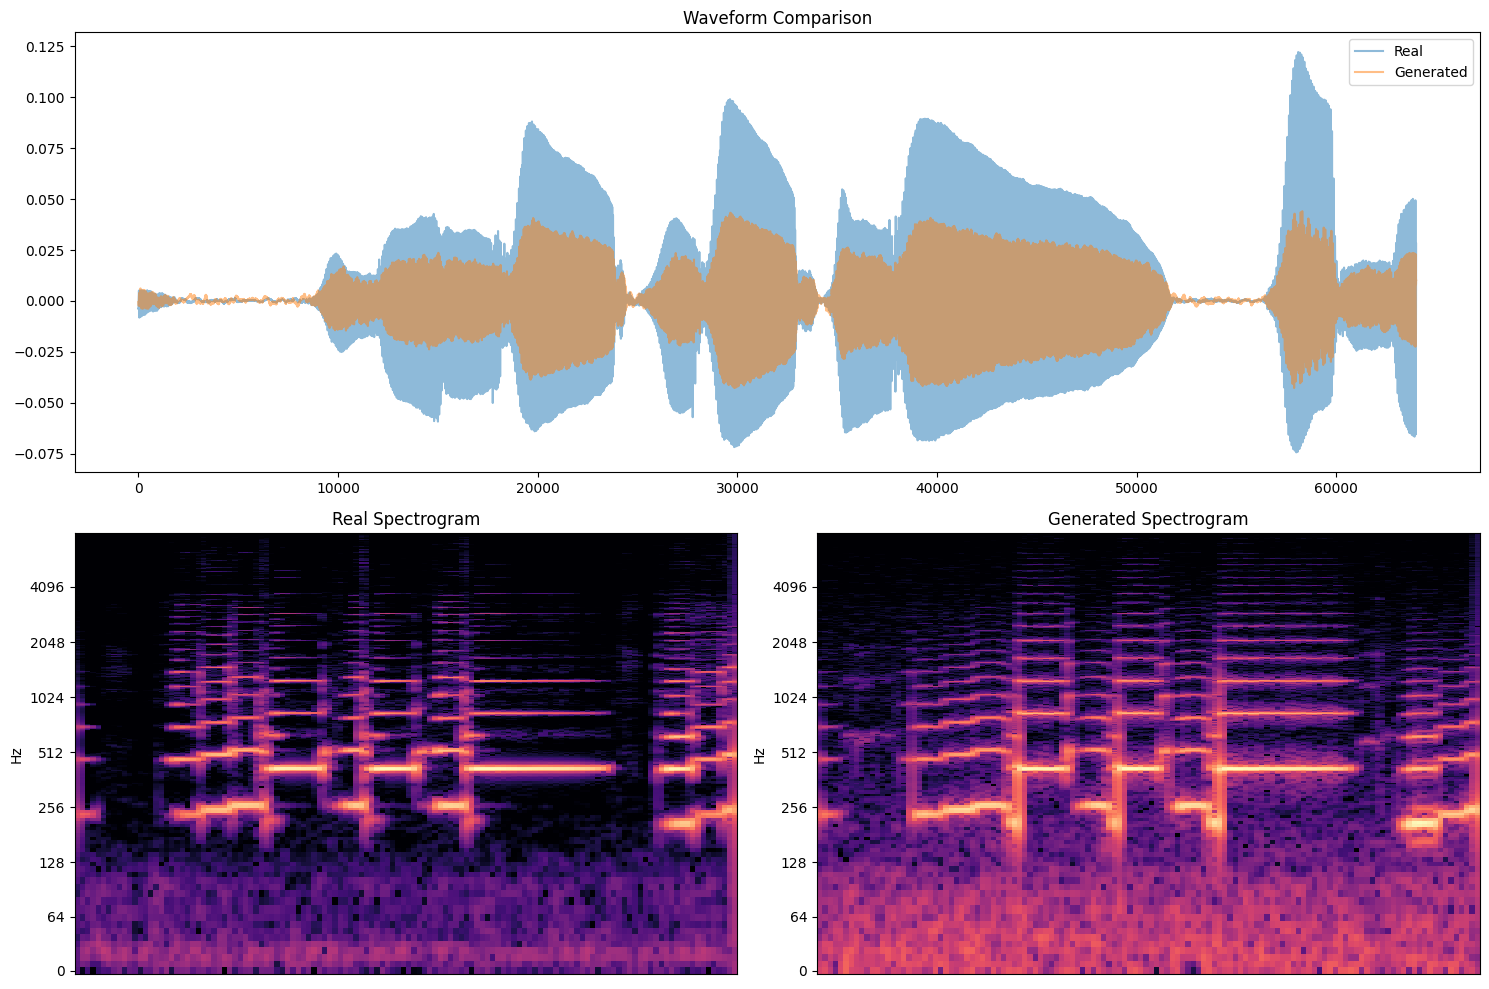

In [6]:
# 評価実行
generator, train_dataset = main(mode = "test")
test_reconstruction(generator, train_dataset, "saved_checkpoint/checkpoint_epoch_20.pt", idx=10)